In [27]:
from langchain_groq import ChatGroq
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [28]:
load_dotenv()

llm = ChatGroq(model="openai/gpt-oss-20b")

In [29]:
class JokeState(TypedDict):

    topic : str
    joke : str
    explanation : str

In [30]:
def generate_joke(state: JokeState):

    prompt= f"generate a joke on the given topic{state["topic"]}"
    response = llm.invoke(prompt).content
    return {'joke': response}

In [31]:
def generate_explanation(state: JokeState):

    prompt = f'Write an explanation under 30 words for the joke - {state['joke']}'
    response = llm.invoke(prompt).content
    return {'explanation': response}

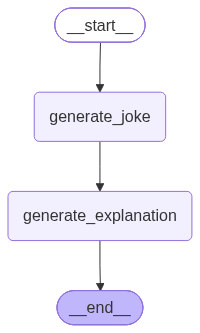

In [32]:
# let's build Graph
graph = StateGraph(JokeState)

# nodes
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

# edges
graph.add_edge(START, "generate_joke")
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [33]:
config1 = {'configurable' : {"thread_id" : "1"}}
workflow.invoke({'topic': 'Pizza'}, config=config1)

{'topic': 'Pizza',
 'joke': 'Why did the pizza start a band?  \nBecause it wanted to *cheese* the world with its *crust*‑worthy riffs!',
 'explanation': 'It’s a punny play on pizza words—“cheese” and “crust”—turned into musical terms, so the pizza “wants to cheese the world” with crust‑worthy riffs.'}

In [34]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza start a band?  \nBecause it wanted to *cheese* the world with its *crust*‑worthy riffs!', 'explanation': 'It’s a punny play on pizza words—“cheese” and “crust”—turned into musical terms, so the pizza “wants to cheese the world” with crust‑worthy riffs.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19af72-4d12-6b6d-8002-95bf9794f8c9'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-18T11:22:49.048324+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19af72-4244-64bb-8001-2a6c2aaed4d6'}}, tasks=(), interrupts=())

In [38]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza start a band?  \nBecause it wanted to *cheese* the world with its *crust*‑worthy riffs!', 'explanation': 'It’s a punny play on pizza words—“cheese” and “crust”—turned into musical terms, so the pizza “wants to cheese the world” with crust‑worthy riffs.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19af72-4d12-6b6d-8002-95bf9794f8c9'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-18T11:22:49.048324+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19af72-4244-64bb-8001-2a6c2aaed4d6'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza start a band?  \nBecause it wanted to *cheese* the world with its *crust*‑worthy riffs!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19af72-4244

In [40]:
config2 = {'configurable':{'thread_id': '2'}}
workflow.invoke({'topic': 'burger'}, config=config2)

{'topic': 'burger',
 'joke': 'Why did the hamburger go to therapy?  \nBecause it had too many *lettuce* issues and was feeling *cheesily* stuck in its *patty* of life!',
 'explanation': 'It puns on food terms—lettuce issues, cheesily stuck, patty of life—making the burger’s emotional woes humorously relatable.'}

In [42]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'burger', 'joke': 'Why did the hamburger go to therapy?  \nBecause it had too many *lettuce* issues and was feeling *cheesily* stuck in its *patty* of life!', 'explanation': 'It puns on food terms—lettuce issues, cheesily stuck, patty of life—making the burger’s emotional woes humorously relatable.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f19af94-07e4-6579-8002-bdc717e4b0e4'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-18T11:37:54.474709+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f19af94-0136-6b7c-8001-8066c7d1be99'}}, tasks=(), interrupts=())

In [43]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'burger', 'joke': 'Why did the hamburger go to therapy?  \nBecause it had too many *lettuce* issues and was feeling *cheesily* stuck in its *patty* of life!', 'explanation': 'It puns on food terms—lettuce issues, cheesily stuck, patty of life—making the burger’s emotional woes humorously relatable.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f19af94-07e4-6579-8002-bdc717e4b0e4'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-18T11:37:54.474709+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f19af94-0136-6b7c-8001-8066c7d1be99'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'burger', 'joke': 'Why did the hamburger go to therapy?  \nBecause it had too many *lettuce* issues and was feeling *cheesily* stuck in its *patty* of life!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '2', 'checkpo